# 03 — Reinforcement Learning: from Bellman to Policy Gradients

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

Classical control steers a system whose equations of motion are known — that is the subject of notebook 05,
and the thread this notebook picks up. Here we ask what survives when the model is *not* known. The state
still moves and the cost is still paid, but the map $f$ and the reward $r$ sit behind an environment that
answers only one question — *you did this, here is what happened next.*

Remarkably, almost nothing is lost. The Bellman equation that characterises the optimal cost does not
care whether we can evaluate $f$; it only cares that $f$ exists. Reinforcement learning is, in large part,
the study of how to solve that equation from samples.

1. **A short history** — the law of effect, Bellman at RAND, and what happened after
2. **Two vocabularies for one problem** — optimal control and reinforcement learning side by side
3. **The Bellman equation** — a contraction, and therefore an algorithm
4. **Continuous time** — the Hamilton–Jacobi–Bellman equation as $\Delta t \to 0$
5. **From control to RL** — Q-learning, and a note on dopamine
6. **Exploration versus exploitation** — bandits, on-policy and off-policy
7. **Pontryagin's maximum principle** — the adjoint, direct shooting, and a trip to the Moon
8. **Markov decision processes** — the probabilistic setting
9. **The policy gradient theorem** — and REINFORCE on a problem whose answer we know
10. **PPO** — a pendulum that teaches itself to swing up
11. **What we left out**

Everything runs on `torch` + `numpy` + `matplotlib`. There is no RL library and no simulator package: every
environment in the notebook is three or four lines of arithmetic, so that nothing is hidden.

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import animation
from torch.distributions import Normal
from IPython.display import HTML

rng = np.random.default_rng(0)
torch.manual_seed(0)

# The palette of the course
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
GREY, INK = "#9a9890", "#0b0b0b"
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA]),
    "axes.grid": False, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
})

## 1. A short history

In 1898 [Edward Thorndike](https://psychclassics.yorku.ca/Thorndike/Animal/) put cats in puzzle boxes and
timed how long they took to escape. The times fell with repetition, and from this he formulated the **law of
effect**: responses followed by satisfaction become more likely, responses followed by discomfort less so.
[Pavlov](https://www.nobelprize.org/prizes/medicine/1904/pavlov/facts/) showed around the same time that
dogs can be conditioned to anticipate a stimulus, and in the 1930s
[B. F. Skinner](https://doi.org/10.1037/h0058412) made the shaping of voluntary behaviour by reinforcement
into an experimental science. None of this was mathematics, but it fixed the vocabulary — *state*,
*action*, *reward* — that the mathematics would later use.

The mathematics arrived from a different direction. In the early 1950s
[Richard Bellman](https://doi.org/10.1073/pnas.38.8.716) was at RAND working for the U.S. Air Force on
multi-stage decisions under uncertainty: how many aircraft to commit at each stage of a mission. The method
he found — solve the last stage first, then work backwards — he called **dynamic programming**, reportedly
because "programming" sounded respectable to his sponsors and "dynamic" was impossible to use pejoratively.
Out of it came the equation that carries his name, the recognition that it is a fixed-point problem, and
the phrase **curse of dimensionality** for the reason you cannot simply solve it on a grid. By the end of
the decade he had pushed it into continuous time, where it generalises the Hamilton–Jacobi equation of the
1830s. In parallel, [Pontryagin's group](https://www.mathnet.ru/eng/im3547) in Moscow was deriving necessary
conditions for optimal missile trajectories, and [Kalman](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf)
was writing down the LQR of notebook 05.

Learning and control met in the late 1980s. [Sutton's temporal-difference methods](https://doi.org/10.1007/BF00115009)
treated the Bellman equation as something to be satisfied *on average along sampled trajectories*;
[Watkins' Q-learning](https://doi.org/10.1007/BF00992698) made that idea converge to the optimal value
without ever estimating the dynamics. [Williams](https://doi.org/10.1007/BF00992696) showed that one can
differentiate the expected return of a stochastic policy using nothing but rollouts. Then in 1997
[Schultz, Dayan and Montague](https://doi.org/10.1126/science.275.5306.1593) reported that midbrain
dopamine neurons fire in proportion to a *reward-prediction error* — the same quantity $\delta_t$ that sits
inside the Q-learning update. The algorithm had been found twice.

What followed is mostly a story of function approximation: [TD-Gammon](https://doi.org/10.1145/203330.203343)
in 1992, [DQN on Atari](https://doi.org/10.1038/nature14236) in 2015, [AlphaGo](https://doi.org/10.1038/nature16961)
in 2016, [PPO](https://arxiv.org/abs/1707.06347) in 2017, and from 2022 the use of policy gradients to
align language models with human preferences.

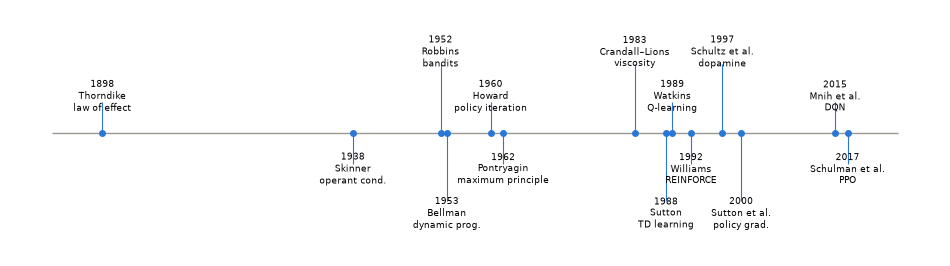

In [2]:
MILESTONES = [
    (1898, "Thorndike\nlaw of effect"), (1938, "Skinner\noperant cond."),
    (1952, "Robbins\nbandits"), (1953, "Bellman\ndynamic prog."),
    (1960, "Howard\npolicy iteration"), (1962, "Pontryagin\nmaximum principle"),
    (1983, "Crandall–Lions\nviscosity"), (1988, "Sutton\nTD learning"),
    (1989, "Watkins\nQ-learning"), (1992, "Williams\nREINFORCE"),
    (1997, "Schultz et al.\ndopamine"), (2000, "Sutton et al.\npolicy grad."),
    (2015, "Mnih et al.\nDQN"), (2017, "Schulman et al.\nPPO"),
]
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.hlines(0, 1890, 2025, color=GREY, lw=1)
for k, (year, name) in enumerate(MILESTONES):
    h = [0.45, -0.45, 1.0, -1.0][k % 4]
    ax.vlines(year, 0, h, color=BLUE, lw=0.8)
    ax.plot(year, 0, "o", ms=4, color=BLUE)
    ax.text(year, 1.18 * h, f"{year}\n{name}", ha="center", va="center", fontsize=6.5)
ax.set(ylim=(-1.8, 1.8)); ax.axis("off")
plt.show()

## 2. Two vocabularies for one problem

Control theory and reinforcement learning describe the same object with different letters. The table below
is a dictionary; it is worth reading once carefully, because every formula later in the notebook can be
written in either column.

| Concept | Optimal control | Reinforcement learning |
|---|---|---|
| State | $x_t \in \mathcal{X}$ | $s_t \in \mathcal{S}$ |
| Action | $u_t \in \mathcal{U}$ | $a_t \in \mathcal{A}$ |
| Dynamics | $x_{t+1} = f(x_t, u_t)$ | $s_{t+1} \sim P(\cdot \mid s_t, a_t)$ |
| Decision rule | control signal $u_t$ | policy $a_t \sim \pi(\cdot\mid s_t)$ |
| Running objective | cost $\ell(x_t, u_t)$ | reward $r(s_t, a_t)$ |
| Total objective | $J(x) = \inf_{u(\cdot)} \sum_{t\ge 0} \gamma^t \ell(x_t,u_t)$ | $V(s) = \sup_{\pi} \mathbb{E}\big[\sum_{t\ge 0}\gamma^t r(s_t,a_t)\big]$ |
| Model | $f$ and $\ell$ are **known** | $f$ and $r$ are **unknown** |

The last row is the only substantive difference, and the sign in the second-to-last is pure convention
(a reward is a negative cost). We will use the control letters $x, u$ while the model is known, and switch
to $s, a$ in §5 when it stops being known.

Three examples show how wide the setting is.

| | **Chess** | **LQR** | **Heat equation** |
|---|---|---|---|
| State space | legal positions, $\lvert\mathcal{X}\rvert \approx 10^{43}$ | $x \in \mathbb{R}^n$ | $y(t,\cdot) \in L^2(\Omega)$ |
| Action space | legal moves at $x$ | $u \in \mathbb{R}^m$ | $u(t,\cdot)$ supported on $\omega \subset \Omega$ |
| Dynamics | $x_{t+1} = f(x_t,u_t)$, deterministic | $\dot x = Ax + Bu$ | $\partial_t y = \Delta y + u \mathbf{1}_\omega$ |
| Objective | $\pm 1$ at checkmate, $0$ otherwise | $\int_0^\infty x^\top Q x + u^\top R u \, dt$ | $\int_0^\infty \lVert y - y^\star\rVert^2 + \lVert u\rVert^2 dt$ |
| Difficulty | finite but astronomically large | solved in closed form | infinite-dimensional |

Chess is finite, and completely intractable by enumeration. LQR is continuous and infinite-horizon, and
reduces to the algebraic Riccati equation $A^\top P + PA - PBR^{-1}B^\top P + Q = 0$ with the linear
feedback $u^\star = -R^{-1}B^\top P x$, which is the subject of notebook 05. The heat equation lives in a
Hilbert space. The Bellman equation of the next section is indifferent to all three.

## 3. The Bellman equation

Fix a deterministic system and an infinite horizon with discount $\gamma \in [0,1)$:

$$x_{t+1} = f(x_t, u_t), \qquad x_0 = x, \qquad V(x) := \sup_{u(\cdot)} \sum_{t=0}^\infty \gamma^t r(x_t, u_t).$$

**Theorem (Bellman).** The value function satisfies

$$V(x) = \max_{u \in \mathcal{U}} \big\{ r(x,u) + \gamma\, V\big(f(x,u)\big) \big\},$$

and the policy $\pi^\star(x) \in \arg\max_u \{ r(x,u) + \gamma V(f(x,u))\}$ is optimal.

*Proof.* Split the control sequence as $u = (u_0, u^+)$ with $u^+ = (u_1, u_2, \dots)$. Then

$$
\begin{aligned}
V(x) &= \sup_{u} \sum_{t\ge 0} \gamma^t r(x_t,u_t)
     = \max_{u_0} \sup_{u^+} \Big\{ r(x,u_0) + \gamma \sum_{t\ge 0}\gamma^{t} r(x_{t+1},u_{t+1}) \Big\} \\
     &= \max_{u_0} \Big\{ r(x,u_0) + \gamma \sup_{u^+} \sum_{t \ge 0}\gamma^{t} r(x_{t+1},u_{t+1}) \Big\}
     = \max_{u_0} \big\{ r(x,u_0) + \gamma V\big(f(x,u_0)\big) \big\}.
\end{aligned}
$$

The third equality is the whole content of the argument: $r(x,u_0)$ does not depend on $u^+$, so it leaves
the inner supremum, and what remains is by definition the value of the state $f(x,u_0)$. This is the
**principle of optimality** — *the tail of an optimal plan is an optimal plan for the tail.*

### A contraction, and therefore an algorithm

Define the **Bellman operator** on bounded functions $V : \mathcal{X} \to \mathbb{R}$,

$$(\mathcal{T}V)(x) := \max_{u \in \mathcal{U}} \big\{ r(x,u) + \gamma\, V(f(x,u)) \big\}.$$

**Theorem.** $\mathcal{T}$ is a $\gamma$-contraction in the supremum norm:
$\lVert \mathcal{T}V - \mathcal{T}W \rVert_\infty \le \gamma \lVert V - W \rVert_\infty$.

*Proof.* Fix $x$ and use $\lvert \max_u F_u - \max_u G_u \rvert \le \max_u \lvert F_u - G_u \rvert$:

$$\lvert (\mathcal{T}V)(x) - (\mathcal{T}W)(x)\rvert \le \max_u \gamma \big\lvert V(f(x,u)) - W(f(x,u)) \big\rvert \le \gamma \lVert V - W\rVert_\infty. \qquad \square$$

By the Banach fixed-point theorem $V^\star$ is the *unique* bounded solution of $\mathcal{T}V = V$, and
**value iteration** $V_{k+1} = \mathcal{T}V_k$ converges from any starting point:

$$\lVert V_k - V^\star \rVert_\infty \le \gamma^k \lVert V_0 - V^\star\rVert_\infty,
\qquad \lVert V_k - V^\star \rVert_\infty \le \frac{\gamma}{1-\gamma}\,\lVert V_k - V_{k-1}\rVert_\infty .$$

The second bound is computable, so it is the one used as a stopping rule. Note what the theorem costs:
one sweep evaluates every pair $(x,u)$, i.e. $\mathcal{O}(\lvert\mathcal{X}\rvert\lvert\mathcal{U}\rvert)$
work, *and it needs $f$ and $r$*. For chess that is $10^{43}$ states; this is Bellman's curse of
dimensionality, and it is the reason the rest of the notebook exists.

### Value iteration on a grid world

The environment: a grid with walls, a goal $\mathsf{G}$ worth $+1$ and a pit $\mathsf{P}$ worth $-1$, both
absorbing. Four actions; walking into a wall leaves the state unchanged. There is no running reward, so
$V^\star(x) = \gamma^{\,d(x)-1}$ with $d$ the number of steps of the best route — discounting alone is what
makes the agent hurry.

In [3]:
MAZE = np.array([list(row) for row in [
    "S........", ".........", "..#####..", "..#...#..",
    "..#.#.#..", "....#....", ".#####.#.", ".......PG"]])
MOVES = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]])      # up, down, left, right
GAMMA, (H, W) = 0.95, MAZE.shape

free = np.argwhere(MAZE != "#")                           # the state space: the non-wall cells
idx = -np.ones((H, W), int); idx[tuple(free.T)] = np.arange(len(free))
term = np.isin(MAZE[tuple(free.T)], ["G", "P"])           # absorbing states
nb = np.clip(free[:, None] + MOVES, 0, [H - 1, W - 1])    # candidate next cells, (n_states, 4, 2)
wall = idx[nb[..., 0], nb[..., 1]] < 0
NEXT = np.where(wall, np.arange(len(free))[:, None], idx[nb[..., 0], nb[..., 1]])     # f(x, u)
tgt = MAZE[nb[..., 0], nb[..., 1]]
R = np.where(wall, 0.0, np.select([tgt == "G", tgt == "P"], [1.0, -1.0], 0.0))        # r(x, u)

In [4]:
def bellman(V):                                           # one application of the operator T
    return np.where(term, 0.0, (R + GAMMA * V[NEXT]).max(1))

V, hist = rng.random(len(free)), []
for k in range(120):
    hist.append(V); V = bellman(V)
V_star = V
print(f"fixed-point residual ||TV* - V*||_inf = {np.abs(bellman(V_star) - V_star).max():.2e}")

fixed-point residual ||TV* - V*||_inf = 0.00e+00


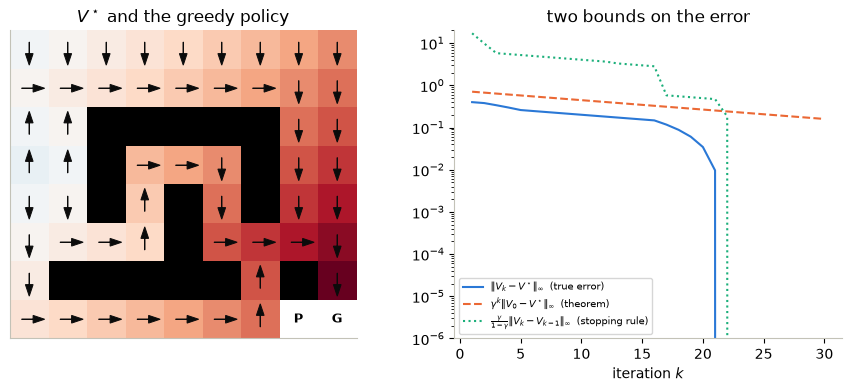

In [5]:
err = np.array([np.abs(v - V_star).max() for v in hist])
pi_star = (R + GAMMA * V_star[NEXT]).argmax(1)            # the greedy policy

def draw_values(ax, V, policy):
    grid = np.full((H, W), np.nan); grid[tuple(free.T)] = np.where(term, np.nan, V)
    ax.imshow(grid, cmap="RdBu_r", vmin=0, vmax=1)
    ax.imshow(np.where(MAZE == "#", 0.0, np.nan), cmap="gray", vmin=0, vmax=1)
    for s, (i, j) in enumerate(free):
        if term[s]:
            ax.text(j, i, MAZE[i, j], ha="center", va="center", fontsize=9, weight="bold")
        else:
            d = MOVES[policy[s]]
            ax.arrow(j - .2 * d[1], i - .2 * d[0], .3 * d[1], .3 * d[0], head_width=.2, color=INK, lw=.7)
    ax.set_xticks([]); ax.set_yticks([])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
draw_values(a0, V_star, pi_star); a0.set_title(r"$V^\star$ and the greedy policy")
ks = np.arange(1, 31)
a1.semilogy(ks, err[ks], color=BLUE, label=r"$\|V_k - V^\star\|_\infty$  (true error)")
a1.semilogy(ks, GAMMA ** ks * err[0], "--", color=ORANGE, label=r"$\gamma^k\|V_0-V^\star\|_\infty$  (theorem)")
a1.semilogy(ks, GAMMA / (1 - GAMMA) * np.abs(np.diff(hist, axis=0)).max(1)[ks - 1], ":",
            color=AQUA, label=r"$\frac{\gamma}{1-\gamma}\|V_k-V_{k-1}\|_\infty$  (stopping rule)")
a1.set(xlabel="iteration $k$", ylim=(1e-6, 20)); a1.legend(fontsize=7, loc="lower left")
a1.set_title("two bounds on the error")
plt.show()

Both bounds hold, and both are pessimistic. In fact the iteration terminates *exactly* after about twenty
sweeps, because the dynamics are deterministic and the rewarding states are absorbing: once the wavefront
of correct values has crossed the grid there is nothing left for an error to ride on. The $\gamma$-contraction
is a worst-case guarantee over all problems, not a prediction for any particular one — but it is the
computable one, and the dotted curve is the version you would actually program as a stopping test.

The policy field detours around the pit even where the pit sits on the shortest route: the cell to the left
of $\mathsf{P}$ points *up*, buying two extra steps of discount rather than a $-1$.

The animation below runs the same iteration from $V_0 = 0$ and shows what the proof hides: value iteration
is information spreading backwards from the reward, one step of the dynamics per sweep. The arrows are
meaningless until the wavefront reaches them.

In [6]:
V, frames = np.zeros(len(free)), []
for k in range(26):
    frames.append((V, (R + GAMMA * V[NEXT]).argmax(1))); V = bellman(V)

fig, ax = plt.subplots(figsize=(4.4, 4))
def draw(k):
    ax.clear(); draw_values(ax, *frames[k]); ax.set_title(f"value iteration, $k = {k}$")
anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=350)
plt.close(fig)
HTML(anim.to_jshtml())

## 4. Continuous time: the Hamilton–Jacobi–Bellman equation

The grid world was discrete by construction. A mechanical system is not, and the discrete Bellman equation
has a continuous-time limit.

| | **Discrete time** | **Continuous time** |
|---|---|---|
| Dynamics | $x_{t+1} = f(x_t,u_t)$ | $\dot x_t = f(x_t,u_t)$ |
| Value | $V(x) = \sup \sum_{t\ge0}\gamma^t r(x_t,u_t)$ | $V(x) = \sup \int_0^\infty \gamma^t\, r(x_t,u_t)\,dt$ |
| Equation | $V(x) = \max_u \{ r + \gamma V(f(x,u))\}$ | $-\ln(\gamma)\,V(x) = \max_u \{ r(x,u) + \nabla V(x)^\top f(x,u)\}$ |

*Derivation.* Take a step of length $\Delta t$. The reward accrued is $r(x,u)\Delta t$, the discount applied
is $\gamma^{\Delta t}$, and the state moves to $x + f(x,u)\Delta t$. The discrete Bellman equation reads

$$V(x) = \max_u \Big\{ r(x,u)\Delta t + \gamma^{\Delta t}\, V\big(x + f(x,u)\Delta t\big)\Big\}.$$

Expand both the discount and the value to first order, $\gamma^{\Delta t} = 1 + \ln(\gamma)\Delta t + o(\Delta t)$
and $V(x + f\Delta t) = V(x) + \nabla V(x)^\top f \Delta t + o(\Delta t)$:

$$V(x) = \max_u \Big\{ r\Delta t + \big(1 + \ln(\gamma)\Delta t\big)\big[V(x) + \nabla V(x)^\top f\,\Delta t\big]\Big\} + o(\Delta t).$$

Cancel $V(x)$ from both sides, divide by $\Delta t$ and let $\Delta t \to 0$:

$$0 = \max_{u\in\mathcal{U}} \Big\{ r(x,u) + \nabla V(x)^\top f(x,u) + \ln(\gamma) V(x)\Big\}.$$

Writing $\gamma = e^{-\rho}$ puts it in its usual form, $\rho V = \max_u \{ r + \nabla V^\top f\}$. This is
the **Hamilton–Jacobi–Bellman** equation: a first-order, fully nonlinear PDE on the state space. Its
solutions are generally not differentiable — the max of smooth functions develops kinks — and the right
notion is a [*viscosity solution*](https://doi.org/10.1090/S0002-9947-1983-0690039-8) (Crandall–Lions,
1983), for which existence and uniqueness do hold.

### A case where we know the answer

Take the scalar problem $\dot x = ax + bu$ with reward $r(x,u) = -(qx^2 + \mathsf{r}u^2)$ and discount
$\rho$. Try $V(x) = -p x^2$, so $\nabla V = -2px$. The maximisation over $u$ is a concave quadratic,
solved by $u^\star = -(pb/\mathsf{r})\,x$, and substituting it back leaves a scalar algebraic equation:

$$\frac{b^2}{\mathsf{r}}\,p^2 + (\rho - 2a)\,p - q = 0, \qquad u^\star = -\frac{pb}{\mathsf{r}}\,x .$$

At $\rho = 0$ this is exactly the algebraic Riccati equation of notebook 05. We can now check the
derivation numerically: fix $\Delta t$, iterate the *discrete* Bellman backup to its fixed point $p_{\Delta t}$,
and watch it approach the root $p^\star$ of the equation above. The backup preserves the quadratic form, so
no grid is needed — the value function is one number.

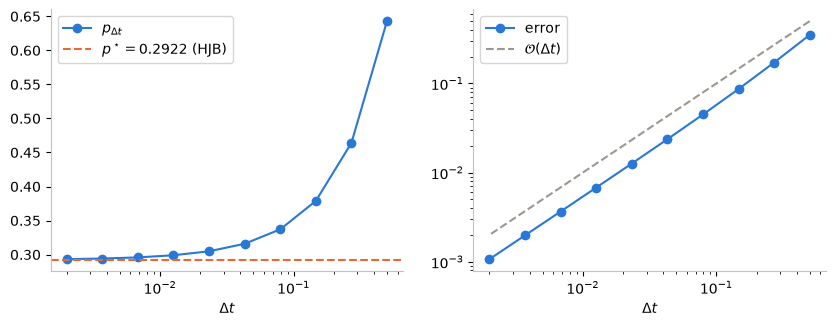

continuous-time optimal feedback:  u = -2.9221 x
its Delta t = 0.1 counterpart:     u = -2.4951 x


In [7]:
A_LQ, B_LQ, Q_LQ, R_LQ, RHO = 0.0, 1.0, 1.0, 0.1, 0.5
p_star = np.roots([B_LQ ** 2 / R_LQ, RHO - 2 * A_LQ, -Q_LQ]).max()          # the HJB / Riccati root

def gain(p, dt):                                                  # the maximiser, u = gain * x
    g = np.exp(-RHO * dt)
    return -g * p * B_LQ * (1 + A_LQ * dt) / (R_LQ + g * p * B_LQ ** 2 * dt)

def p_discrete(dt):                                               # fixed point of the Delta-t backup
    g, p = np.exp(-RHO * dt), 0.0
    for _ in range(int(60 / dt)):
        k = gain(p, dt)
        p = (Q_LQ + R_LQ * k ** 2) * dt + g * p * (1 + (A_LQ + B_LQ * k) * dt) ** 2
    return p

dts = np.geomspace(0.5, 2e-3, 10)
ps = np.array([p_discrete(dt) for dt in dts])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.4))
a0.semilogx(dts, ps, "o-", color=BLUE, label=r"$p_{\Delta t}$")
a0.axhline(p_star, ls="--", color=ORANGE, label=rf"$p^\star = {p_star:.4f}$ (HJB)")
a0.set_xlabel(r"$\Delta t$"); a0.legend()
a1.loglog(dts, np.abs(ps - p_star), "o-", color=BLUE, label="error")
a1.loglog(dts, dts, "--", color=GREY, label=r"$\mathcal{O}(\Delta t)$")
a1.set_xlabel(r"$\Delta t$"); a1.legend()
plt.show()
print(f"continuous-time optimal feedback:  u = {-p_star * B_LQ / R_LQ:.4f} x")
print(f"its Delta t = 0.1 counterpart:     u = {gain(p_discrete(0.1), 0.1):.4f} x")

The error is first order in $\Delta t$, which is what an Euler discretisation of the dynamics together with
a first-order expansion of $\gamma^{\Delta t}$ should give.

Keep the second number in mind. An agent that acts every $\Delta t = 0.1$ is solving the discrete problem,
not the continuous one, so $-2.4951$ — not $-2.9221$ — is the gain it should find. In §9 we will hand that
problem to an algorithm that knows neither $a$, $b$, $q$ nor $\mathsf{r}$, and see what it comes back with.

## 5. From control to RL

Everything so far assumed we could *evaluate* $f$ and $r$: value iteration asks for $r(x,u)$ and
$f(x,u)$ at every pair. Reinforcement learning drops that assumption. The agent may only act, and observe:

- it sees a state $s_t$,
- it chooses an action $a_t \sim \pi(\cdot \mid s_t)$,
- it receives a reward $r_t$,
- it finds itself in a new state $s_{t+1}$.

What it collects is a stream of tuples $\{(s_t, a_t, r_t, s_{t+1})\}_t$ and nothing else. Two families of
algorithms grow out of this. **Value-based** methods estimate $V$ or $Q$ from the stream and read off a
policy greedily; **policy-based** methods parametrise $\pi_\theta$ and improve it directly. This section
and the next do the first; §9 and §10 do the second.

### Q-learning

The obstacle to using $V$ without a model is the $\max_u \{ r(x,u) + \gamma V(f(x,u))\}$: picking the
greedy action requires knowing where each action leads. So move the expectation inside and define the
**action-value function**

$$Q(x,u) := r(x,u) + \gamma V\big(f(x,u)\big), \qquad\text{so that}\qquad V(x) = \max_{u} Q(x,u).$$

Substituting the second identity into the first eliminates $V$ entirely:

$$\boxed{\;Q(x,u) = r(x,u) + \gamma \max_{u'} Q\big(f(x,u), u'\big)\;}$$

and the greedy policy $\pi^\star(x) \in \arg\max_u Q^\star(x,u)$ is optimal — now computable from $Q$ alone.
The corresponding operator $(\mathcal{T}Q)(x,u) := r(x,u) + \gamma\max_{u'}Q(f(x,u),u')$ is again a
$\gamma$-contraction, by the same two lines as before, so $Q^\star$ exists and is unique.

This is still a model-based identity. The step that makes it an algorithm is to stop *solving* the equation
and start *correcting* towards it, one observed transition at a time. Given a sample
$(s_t, a_t, r_t, s_{t+1})$, form the **temporal-difference error**

$$\delta_t := \underbrace{r_t + \gamma \max_{a'} Q(s_{t+1},a')}_{\text{what the data says}} \;-\; \underbrace{Q(s_t,a_t)}_{\text{what we believed}},
\qquad Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\,\delta_t .$$

$\delta_t$ is an unbiased sample of the Bellman residual at $(s_t,a_t)$, so the update is a stochastic
approximation to $Q \leftarrow \mathcal{T}Q$. [Watkins and Dayan (1992)](https://doi.org/10.1007/BF00992698)
proved it converges to $Q^\star$ with probability one, provided every state–action pair is visited
infinitely often and the step sizes satisfy the Robbins–Monro conditions
$\sum_t \alpha_t = \infty$, $\sum_t \alpha_t^2 < \infty$. The first condition is not a technicality: it is
the whole subject of §6.

> **An aside on dopamine.** In 1997 [Schultz, Dayan and Montague](https://doi.org/10.1126/science.275.5306.1593)
> recorded midbrain dopamine neurons in monkeys. The neurons fired when an unexpected reward arrived; after
> a predictive cue was learned, they fired at the *cue* instead; and when an expected reward failed to
> appear, their activity *dipped below baseline* at exactly the moment it was due. That is the sign pattern
> of $\delta_t$, not of reward. The reward-prediction-error hypothesis — that dopamine broadcasts $\delta_t$
> — remains one of the closest contacts between a machine-learning algorithm and a measured biological
> signal.

Below, the same grid world as §3, but the agent is given only `NEXT` and `R` as an *oracle it may query at
its current state*: it never reads them as tables, never sweeps over the state space, and never sees a
transition it did not itself take.

In [8]:
start = np.flatnonzero(~term)                       # episodes begin anywhere, so every pair is reachable
Q, s, err_q = np.ones((len(free), 4)), rng.choice(start), []    # optimistic init: unseen actions look good

for t in range(60_000):
    a = rng.integers(4) if rng.random() < 0.1 else Q[s].argmax()          # epsilon-greedy
    s2, r = NEXT[s, a], R[s, a]                                           # the environment answers
    delta = r + GAMMA * (0.0 if term[s2] else Q[s2].max()) - Q[s, a]      # temporal-difference error
    Q[s, a] += 0.2 * delta
    s = rng.choice(start) if term[s2] else s2
    if t % 500 == 0:
        err_q.append(np.abs(np.where(term, 0, Q.max(1)) - V_star).max())

pi_q = Q.argmax(1)
print(f"||max_a Q - V*||_inf        = {err_q[-1]:.2e}")
print(f"sub-optimality of greedy pi = {np.abs(V_star - (R + GAMMA * V_star[NEXT])[np.arange(len(free)), pi_q])[~term].max():.2e}")

||max_a Q - V*||_inf        = 2.99e-04
sub-optimality of greedy pi = 0.00e+00


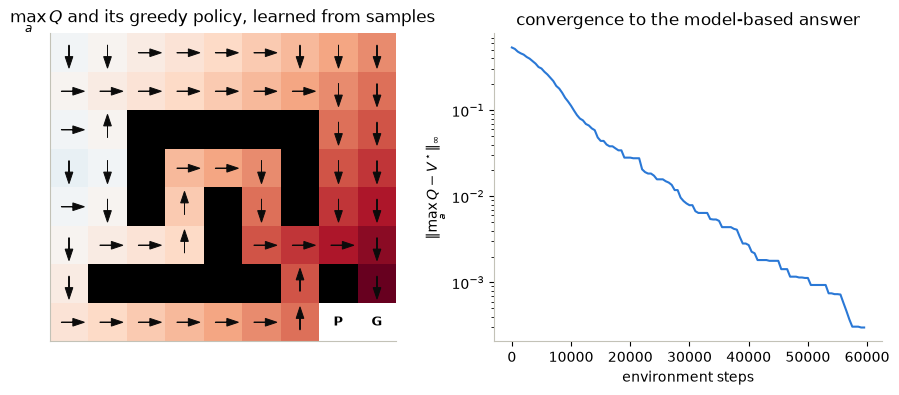

In [9]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
draw_values(a0, np.where(term, 0, Q.max(1)), pi_q)
a0.set_title(r"$\max_a Q$ and its greedy policy, learned from samples")
a1.semilogy(np.arange(len(err_q)) * 500, err_q, color=BLUE)
a1.set_xlabel("environment steps"); a1.set_ylabel(r"$\|\max_a Q - V^\star\|_\infty$")
a1.set_title("convergence to the model-based answer")
plt.show()

The learned value field is indistinguishable from the one value iteration computed with full knowledge of
$f$ and $r$, and the induced policy is exactly optimal (where the arrows differ, the two actions have equal
value). The price is on the horizontal axis. Value iteration settled in a couple of dozen sweeps; Q-learning
needed tens of thousands of steps of interaction to reach the same answer, and it had to *walk* to every
state it wanted to learn about. In dynamic programming the currency is computation; in reinforcement
learning it is experience.

Two details in the code carry weight. `Q = np.ones(...)` is *optimistic initialisation*: since true values
are below $1$, any action never tried looks better than one already tried, and the agent sweeps its options
without being told to. And episodes restart from a uniformly random state, which is the cheapest way to
honour Watkins' "every pair infinitely often". Remove either and the run above stalls: with $Q\equiv 0$
and ties broken by index, the greedy action is *up* in every state, and the agent spends its whole budget
pressed against the ceiling of the maze.

## 6. Exploration versus exploitation

Watkins' theorem needs every state–action pair visited infinitely often, but the policy we are learning is
greedy, and a greedy policy visits what it already likes. The standard compromise is the
**$\varepsilon$-greedy** rule: behave greedily, except that with probability $\varepsilon$ act at random,

$$a_t \sim \begin{cases}\arg\max_{a} Q(s_t,a), & \text{with probability } 1-\varepsilon,\\[2pt]
\mathrm{Uniform}(\mathcal{A}), & \text{with probability } \varepsilon.\end{cases}$$

Both extremes fail. At $\varepsilon = 0$ the agent never revises a bad early estimate; at $\varepsilon = 1$
it collects unbiased data about a policy it will never follow. The cleanest place to see the trade-off is
the **multi-armed bandit** of [Robbins (1952)](https://doi.org/10.1090/S0002-9904-1952-09620-8): a single
state, $K$ actions, and reward $r(a) \sim \mathcal{N}(\mu_a, 1)$. Here $V^\star = \max_a \mu_a$ and
$Q(a) \to \mu_a$ is just an average of samples, so nothing but the exploration question remains.

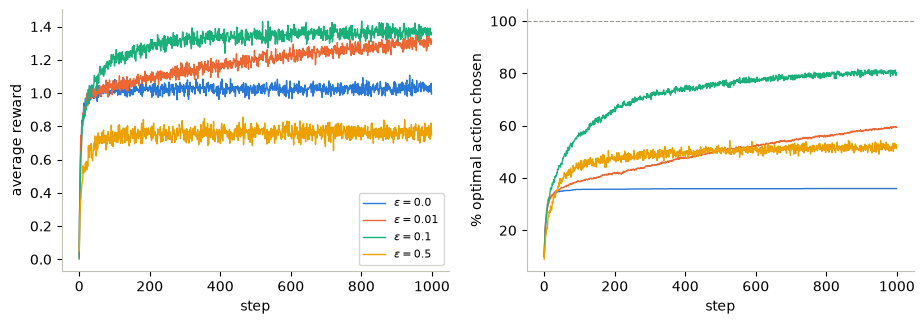

In [10]:
K, RUNS, STEPS = 10, 2000, 1000
mu = rng.standard_normal((RUNS, K))                      # one bandit instance per run
best, ix = mu.argmax(1), np.arange(RUNS)

def run_eps(eps):
    Q, N, out = np.zeros((RUNS, K)), np.zeros((RUNS, K)), np.zeros((STEPS, 2))
    for t in range(STEPS):
        a = np.where(rng.random(RUNS) < eps, rng.integers(K, size=RUNS), Q.argmax(1))
        r = mu[ix, a] + rng.standard_normal(RUNS)
        N[ix, a] += 1
        Q[ix, a] += (r - Q[ix, a]) / N[ix, a]             # running mean = step size 1/N
        out[t] = r.mean(), (a == best).mean()
    return out

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3.4))
for eps in [0.0, 0.01, 0.1, 0.5]:
    out = run_eps(eps)
    a0.plot(out[:, 0], lw=1, label=rf"$\varepsilon = {eps}$"); a1.plot(100 * out[:, 1], lw=1)
a0.set(xlabel="step", ylabel="average reward"); a0.legend(fontsize=8)
a1.set(xlabel="step", ylabel="% optimal action chosen")
a1.axhline(100, color=GREY, lw=0.8, ls="--")
plt.show()

Pure greed ($\varepsilon = 0$) rises fastest for the first few pulls and then stops: it commits to whichever
arm happened to pay first, and after a thousand steps is still choosing the best arm only about a third of
the time. Pure noise ($\varepsilon = 0.5$) does the opposite — it *finds* the best arm reliably and then
throws away half of its pulls on arms it knows are worse, so it earns the least of the four. The two panels
rank these two differently, which is the point: knowing which arm is best and actually playing it are
separate achievements, and $\varepsilon$ decides how much of one you trade for the other.

The useful values are small and positive, and the right one depends on the horizon: on a longer run
$\varepsilon = 0.01$ eventually overtakes $\varepsilon = 0.1$, which is why $\varepsilon$ is normally
annealed towards zero. Modern alternatives replace the uniform noise with something directed: optimism (UCB), posterior
sampling (Thompson), or an entropy bonus in the objective itself, which is the route PPO takes in §10.

### On-policy and off-policy

There are two policies in the room. The **behaviour policy** $\mu$ generates the data; the **target
policy** $\pi$ is the one being improved. Q-learning's update uses $\max_{a'} Q(s_{t+1},a')$ — the value of
the *greedy* action — while the data was gathered by an $\varepsilon$-greedy walk. Target $\neq$ behaviour,
so Q-learning is **off-policy**. Replacing that $\max$ by $Q(s_{t+1}, a_{t+1})$, the action actually taken
next, gives SARSA, which is **on-policy**.

| | **On-policy** ($\mu = \pi$) | **Off-policy** ($\mu \neq \pi$) |
|---|---|---|
| Examples | SARSA, REINFORCE, A2C, TRPO, PPO | Q-learning, DQN, DDPG, TD3, SAC |
| Data | discarded after each update | kept in a replay buffer and reused |
| Sample efficiency | low | high |
| Stability | more stable, simpler theory | can diverge — the *deadly triad* |

The **deadly triad** (Sutton & Barto): bootstrapping, function approximation and off-policy data are each
harmless alone, and jointly can make the iteration diverge — the composition of a $\gamma$-contraction with
a projection onto the span of the features need not be a contraction in any norm. DQN's target networks and
replay buffers exist to make the composition behave.

## 7. Pontryagin's maximum principle

Dynamic programming is not the only route to optimality, and historically it was not the only one being
built. While Bellman was at RAND, [Lev Pontryagin's group](https://www.mathnet.ru/eng/im3547) in Moscow was
working on trajectory optimisation for ballistic missiles, and arrived at necessary conditions of a
completely different shape: no value function on the state space, just two coupled ODEs along a single
trajectory.

Take a **finite horizon** and minimise

$$J(u) = \int_0^T \ell(x_t,u_t)\,dt + \ell_T(x_T), \qquad \dot x_t = f(x_t,u_t),\quad x_0 = x.$$

Introduce the **Hamiltonian** $H(x,u,p) := \ell(x,u) + p^\top f(x,u)$.

**Theorem (Pontryagin, 1956–62).** If $(x^\star, u^\star)$ is optimal, there is an *adjoint* (costate)
$p : [0,T] \to \mathbb{R}^n$ with

$$
\begin{aligned}
\dot x^\star_t &= \nabla_p H = f(x^\star_t, u^\star_t), & x^\star_0 &= x,\\
\dot p_t &= -\nabla_x H = -\nabla_x \ell - (\nabla_x f)^\top p_t, & p_T &= \nabla \ell_T(x^\star_T),\\
u^\star_t &= \arg\min_{u \in \mathcal{U}} H(x^\star_t, u, p_t). &&
\end{aligned}
$$

*Where the adjoint comes from.* Enforce the dynamics with a multiplier $p$ and integrate by parts:

$$\mathcal{L} = \int_0^T \ell\,dt + \ell_T(x_T) + \int_0^T p_t^\top(f - \dot x_t)\,dt,
\qquad \int_0^T p^\top \dot x\,dt = p_T^\top x_T - p_0^\top x_0 - \int_0^T \dot p^\top x\,dt .$$

The first variation, with $\delta x_0 = 0$, is

$$\delta\mathcal{L} = \int_0^T \big(\nabla_x \ell + (\nabla_x f)^\top p + \dot p\big)^\top \delta x\,dt
+ \int_0^T \big(\nabla_u \ell + (\nabla_u f)^\top p\big)^\top \delta u\,dt
+ \big(\nabla \ell_T(x_T) - p_T\big)^\top \delta x_T .$$

Choosing $p$ to annihilate the $\delta x$ terms gives the adjoint equation and its terminal condition, and
what is left multiplying $\delta u$ is the gradient: $\nabla_{u(t)}J = \nabla_u \ell + (\nabla_u f)^\top p_t$.
The multiplier is a sensitivity — in fact $p_t = \nabla_x V(t, x^\star_t)$, which is how the two theories
touch.

| | **HJB** | **PMP** |
|---|---|---|
| Unknown | $V(t,x)$ on $[0,T]\times\mathcal{X}$ | $(x^\star_t, p_t)$ on $[0,T]$ |
| Equation | a PDE on the state space | ODEs along one trajectory |
| Yields | a feedback law $u^\star(x)$ (closed loop) | a control signal $u^\star(t)$ (open loop) |
| Conditions | necessary **and** sufficient | necessary only |
| Cost | exponential in $\dim \mathcal{X}$ | independent of $\dim\mathcal{X}$ |

The last row is why PMP survives in high dimensions and HJB does not, and it is the reason trajectory
optimisation and model predictive control are written this way.

### Direct shooting is reverse-mode autodiff

Discretise with Euler, $x_{t+1} = x_t + \Delta t\, f(x_t,u_t)$, and repeat the Lagrangian argument with
multipliers $\hat p_{t+1}$. What comes out is a backward sweep and a gradient:

$$\hat p_t = \hat p_{t+1} + \Delta t\big(\nabla_x \ell_t + (\nabla_x f_t)^\top \hat p_{t+1}\big),
\qquad \hat p_N = \nabla \ell_T(x_N),
\qquad \nabla_{u_t} J = \Delta t\big(\nabla_u \ell_t + (\nabla_u f_t)^\top \hat p_{t+1}\big).$$

This is *exactly* what reverse-mode automatic differentiation does when you backpropagate through the Euler
unroll — the adjoint $\hat p_t$ is the gradient of the loss with respect to $x_t$, which is the quantity
`backward()` propagates. So **direct shooting** is three lines:

1. forward-simulate $x_0,\dots,x_N$ from the current $u$;
2. call `J.backward()`, which runs the adjoint sweep;
3. step $u \leftarrow u - \eta\,\nabla_u J$, and repeat.

Notebook 02 ran exactly these three lines with $\theta$ in place of $u$ and a data-fitting loss in place of
$\int\ell$; that is all a neural ODE is.

### A trip to the Moon

Planar two-body gravity with the Earth at the origin and the Moon fixed at $(1,0)$, state
$x = (q, v) \in \mathbb{R}^4$, control the thrust acceleration $u \in \mathbb{R}^2$:

$$\dot q = v, \qquad \dot v = -\mu_E\frac{q - q_E}{\lVert q-q_E\rVert^3} - \mu_M\frac{q-q_M}{\lVert q - q_M\rVert^3} + u .$$

The spacecraft starts in a low Earth orbit whose natural apoapsis falls well short of the Moon, so it
cannot coast there — the optimiser must spend fuel. The cost is fuel plus a terminal penalty for missing
the target lunar orbit, with one waypoint term to break the symmetry between going the long way round and
the short way:

$$J(u) = \tfrac12\!\int_0^T \!\lVert u\rVert^2 dt \;+\; w\lVert q_{T/2} - q_M\rVert^2
\;+\; \tfrac{\alpha}{2}\lVert q_T - q^\star\rVert^2 + \tfrac{\beta}{2}\lVert v_T - v^\star\rVert^2 .$$

In [11]:
torch.set_default_dtype(torch.float64)                 # gravity softening and long unrolls want precision
MU_E, MU_M, SOFT = 1.0, 0.05, 1e-3
qE, qM = torch.tensor([0.0, 0.0]), torch.tensor([1.0, 0.0])
x0 = torch.tensor([-0.2, 0.0, 0.0, 2.6])               # low Earth orbit, apoapsis ~0.42 < 1
q_star, v_star = torch.tensor([1.2, 0.0]), torch.tensor([0.0, -0.5])   # circular lunar orbit
N, dt = 550, 2.2 / 550

def f_orbit(x, u):
    q, v = x[:2], x[2:]
    dE, dM = q - qE, q - qM
    a = -MU_E * dE / (dE @ dE + SOFT) ** 1.5 - MU_M * dM / (dM @ dM + SOFT) ** 1.5
    return torch.cat([v, a + u])

def shoot(u):                                          # forward pass = the state equation
    x, xs = x0, [x0]
    for t in range(N):
        x = x + dt * f_orbit(x, u[t]); xs.append(x)
    return torch.stack(xs)

def cost(u, xs):
    return (0.5 * dt * (u ** 2).sum() + 10.0 * ((xs[N // 2, :2] - qM) ** 2).sum()
            + 200.0 * ((xs[-1, :2] - q_star) ** 2).sum() + 50.0 * ((xs[-1, 2:] - v_star) ** 2).sum())

In [12]:
u = torch.zeros(N, 2, requires_grad=True)
opt = torch.optim.Adam([u], lr=2e-2)
snap_at, snaps = np.unique(np.round(np.geomspace(1, 1200, 10)).astype(int)), []

for it in range(1, 1201):
    xs = shoot(u)
    J = cost(u, xs)
    opt.zero_grad(); J.backward(); opt.step()          # backward() IS the adjoint sweep
    if it in snap_at:
        snaps.append(xs.detach().numpy()); print(f"iteration {it:5d}:  J = {J.item():8.3f}")

iteration     1:  J =  192.954
iteration     2:  J =  145.812


iteration     5:  J =   82.499


iteration    11:  J =   53.179


iteration    23:  J =   36.532


iteration    51:  J =   14.991


iteration   113:  J =   10.106


iteration   248:  J =    8.864


iteration   546:  J =    8.062


iteration  1200:  J =    7.528


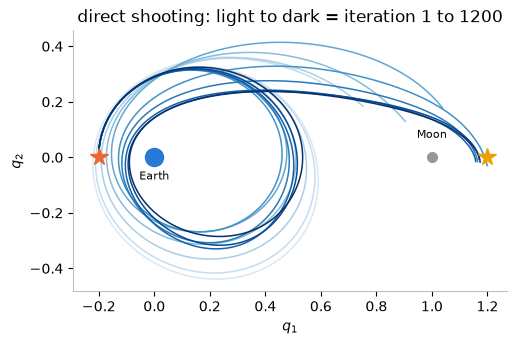

In [13]:
fig, ax = plt.subplots(figsize=(5.6, 4.6))
for i, xs in enumerate(snaps):
    ax.plot(xs[:, 0], xs[:, 1], color=plt.get_cmap("Blues")(0.15 + 0.85 * i / (len(snaps) - 1)), lw=1.1)
ax.plot(*qE, "o", ms=13, color=BLUE); ax.plot(*qM, "o", ms=7, color=GREY)
ax.plot(*x0[:2], "*", ms=13, color=ORANGE); ax.plot(*q_star, "*", ms=13, color=YELLOW)
ax.text(0, -0.08, "Earth", ha="center", fontsize=8); ax.text(1.0, 0.07, "Moon", ha="center", fontsize=8)
ax.set(aspect="equal", xlabel="$q_1$", ylabel="$q_2$", title="direct shooting: light to dark = iteration 1 to 1200")
plt.show()

In [14]:
traj = snaps[-1][::6]
fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.plot(snaps[-1][:, 0], snaps[-1][:, 1], color="#dfe7f2", lw=1)
ax.plot(*qE, "o", ms=13, color=BLUE); ax.plot(*qM, "o", ms=7, color=GREY)
tail, = ax.plot([], [], color=BLUE, lw=1.4)
dot, = ax.plot([], [], "o", ms=5, color=ORANGE)
ax.set(aspect="equal", xticks=[], yticks=[])

def draw(k):
    tail.set_data(traj[:k + 1, 0], traj[:k + 1, 1]); dot.set_data(traj[k:k + 1, 0], traj[k:k + 1, 1])
    ax.set_title(f"$t = {k * 6 * dt:.2f}$")
anim = animation.FuncAnimation(fig, draw, frames=len(traj), interval=70)
plt.close(fig)
HTML(anim.to_jshtml())

The optimiser is never told to spiral. It is told that thrust is expensive, that it must pass near the Moon
at half-time and arrive at $q^\star$ with velocity $v^\star$, and that the gravity of two bodies acts on it.
Everything else — raising the orbit over several revolutions, then committing to a transfer arc — is a
consequence of $\nabla_u J = 0$.

Two caveats worth stating plainly. PMP gives *necessary* conditions, so what we have found is a stationary
point of a non-convex problem; different initialisations of $u$ land on different transfers. And the
solution is **open loop**: a schedule $u^\star(t)$, valid for this initial condition and this model. Perturb
the spacecraft and it is wrong. The standard repair is **model predictive control** — re-solve this problem
from the current state every few seconds and apply only the first control, which is how notebook 05 swings
up a pendulum. It is also the bridge back to reinforcement learning, which buys closed-loop behaviour
outright, at the price of needing far more data.

## 8. Markov decision processes

Everything so far was deterministic: $f$ was a map, and the only randomness was the agent's own
exploration. Real environments are noisy, and the standard object is the **Markov decision process**, a
tuple $\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)$:

- a measurable state space $(\mathcal{S}, \mathcal{F}_\mathcal{S})$ and action space $(\mathcal{A}, \mathcal{F}_\mathcal{A})$;
- a **transition kernel** $P : \mathcal{S}\times\mathcal{A} \to \mathcal{P}(\mathcal{S})$, where
  $P(\cdot\mid s,a)$ is a probability measure and $(s,a)\mapsto P(B\mid s,a)$ is measurable for every
  $B \in \mathcal{F}_\mathcal{S}$:
  $$P(B \mid s,a) = \mathbb{P}\big(S_{t+1}\in B \mid S_t = s,\, A_t = a\big);$$
- a measurable **reward** $r(s,a) = \mathbb{E}[R_{t+1}\mid S_t = s, A_t = a]$;
- a discount $\gamma \in [0,1)$.

The defining assumption is the **Markov property**: for every measurable $B \subseteq \mathcal{S}$,

$$\mathbb{P}\big(S_{t+1} \in B \mid S_0,A_0,\dots,S_t,A_t\big) = P(B\mid S_t,A_t),$$

the future depends on the past only through the present state and action. A **policy** is a kernel
$\pi : \mathcal{S}\to\mathcal{P}(\mathcal{A})$, and the value functions are

$$V^\pi(s) := \mathbb{E}^\pi_s\Big[\sum_{t\ge0}\gamma^t R_{t+1}\Big],
\qquad Q^\pi(s,a) := \mathbb{E}^\pi\Big[\sum_{t\ge0}\gamma^t R_{t+1} \,\Big|\, S_0 = s, A_0 = a\Big].$$

Everything proved in §3 goes through with $V(f(x,u))$ replaced by an integral:

$$V^\star(s) = \sup_{a\in\mathcal{A}}\Big\{ r(s,a) + \gamma\int_\mathcal{S} V^\star(s')\,P(ds'\mid s,a)\Big\}.$$

The contraction proof is unchanged — an integral against a probability measure is an average, and averaging
is a non-expansion in $\lVert\cdot\rVert_\infty$ — so value iteration still converges at rate $\gamma$.

| | **Deterministic (§3–§7)** | **Probabilistic (§8–§10)** |
|---|---|---|
| Dynamics | $s_{t+1} = f(s_t,a_t)$ | $S_{t+1}\sim P(\cdot\mid S_t,A_t)$ |
| Policy | $a_t = \pi(s_t)$ | $A_t \sim \pi(\cdot\mid S_t)$ |
| Reward | $r(s_t,a_t)$ | $r(s,a) = \mathbb{E}[R_{t+1}\mid S_t=s,A_t=a]$ |
| Value | $V^\pi(s) = \sum_{t\ge0}\gamma^t r(s_t,a_t)$ | $V^\pi(s) = \mathbb{E}^\pi_s\big[\sum_{t\ge0}\gamma^t R_{t+1}\big]$ |
| Bellman | $V^\star(s) = \sup_a\{r + \gamma V^\star(f(s,a))\}$ | $V^\star(s) = \sup_a\{r + \gamma\!\int V^\star dP\}$ |

Note that a *stochastic* policy is now a first-class object rather than an exploration hack. For an MDP
with full state observation there is always a deterministic optimal policy, so the randomness buys nothing
at the optimum — but it is what makes $\pi_\theta$ differentiable, which is the whole of the next section.

## 9. The policy gradient theorem

Value-based methods detour through $Q$ and then take an $\arg\max$, which is awkward when $\mathcal{A}$ is
continuous: the greedy step becomes an optimisation problem of its own, solved at every time step.
Policy-based methods remove the detour. Parametrise $\pi_\theta(a\mid s)$ and do gradient ascent on

$$J(\theta) := \mathbb{E}_{\tau\sim p_\theta}\big[G(\tau)\big], \qquad G(\tau) := \sum_{k\ge0}\gamma^k R_{k+1},$$

where the trajectory $\tau = (S_0,A_0,S_1,A_1,\dots)$ has density

$$p_\theta(\tau) = \nu(S_0)\prod_{t\ge0}\pi_\theta(A_t\mid S_t)\,P(S_{t+1}\mid S_t,A_t).$$

The difficulty is that $\theta$ changes the *distribution* being averaged over, not the integrand, and we
cannot differentiate $P$ because we do not know it.

**Theorem ([Sutton et al., 2000](https://proceedings.neurips.cc/paper/1999/hash/464d828b85b0bed98e80ade0a5c43b0f-Abstract.html)).**

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau\sim p_\theta}\Big[\sum_{t\ge0}\gamma^t\,
\nabla_\theta\log\pi_\theta(A_t\mid S_t)\; Q^{\pi_\theta}(S_t,A_t)\Big].$$

*Proof.* **(1) The score trick.** $\lvert G(\tau)\rvert \le \lVert r\rVert_\infty/(1-\gamma)$, so dominated
convergence permits differentiating under the integral; then $\nabla_\theta p_\theta = p_\theta \nabla_\theta \log p_\theta$:

$$\nabla_\theta J = \int G(\tau)\,p_\theta(\tau)\,\nabla_\theta \log p_\theta(\tau)\,d\tau
= \mathbb{E}_\tau\big[G(\tau)\,\nabla_\theta\log p_\theta(\tau)\big].$$

Taking logs of the factorisation, $\nu$ and $P$ are free of $\theta$ and drop out:
$\nabla_\theta \log p_\theta(\tau) = \sum_{t\ge0}\nabla_\theta\log\pi_\theta(A_t\mid S_t)$. **The unknown
dynamics have disappeared** — this is the step that makes the whole method possible.

**(2) The score is centred.** For every fixed $s$,
$\mathbb{E}_{a\sim\pi_\theta}[\nabla_\theta\log\pi_\theta(a\mid s)] = \nabla_\theta\!\int \pi_\theta(a\mid s)\,da = \nabla_\theta 1 = 0.$

**(3) Causality.** Let $\mathcal{F}_t = \sigma(S_0,A_0,R_1,\dots,R_t,S_t)$, the history *before* $A_t$. For
$k < t$ the reward $R_{k+1}$ is $\mathcal{F}_t$-measurable, so by the tower property and step (2),

$$\mathbb{E}\big[R_{k+1}\nabla_\theta\log\pi_\theta(A_t\mid S_t)\big]
= \mathbb{E}\big[R_{k+1}\underbrace{\mathbb{E}[\nabla_\theta\log\pi_\theta(A_t\mid S_t)\mid\mathcal{F}_t]}_{=\,0}\big] = 0 .$$

An action cannot affect a reward that has already been paid, so only $k\ge t$ survives.

**(4) Markov.** With $\mathcal{G}_t = \sigma(\mathcal{F}_t, A_t)$, the law of the future given $\mathcal{G}_t$
depends on the history only through $(S_t,A_t)$, hence
$\mathbb{E}[\sum_{k\ge t}\gamma^{k-t}R_{k+1}\mid\mathcal{G}_t] = Q^{\pi_\theta}(S_t,A_t)$.

**(5) Assemble.** Factor $\gamma^k = \gamma^t\gamma^{k-t}$ and apply the tower with $\mathcal{G}_t$, pulling
out the $\mathcal{G}_t$-measurable score. Summing over $t$ gives the theorem. $\square$

### REINFORCE

$Q^{\pi_\theta}$ is unknown, but by definition it is the conditional mean of the realised return, so along
a sampled rollout $G_t = \sum_{k\ge0}\gamma^k r_{t+k+1}$ is an unbiased estimate of it. Substituting gives
[Williams' REINFORCE (1992)](https://doi.org/10.1007/BF00992696):

1. roll out $\{s_t,a_t,r_{t+1}\}_{t=0}^{T}$ with $a_t\sim\pi_\theta(\cdot\mid s_t)$;
2. form the returns-to-go $G_t$;
3. ascend: $\theta \leftarrow \theta + \eta\sum_t \gamma^t\,\nabla_\theta\log\pi_\theta(a_t\mid s_t)\,G_t$.

Unbiased, and badly behaved: $G_t$ sums an entire trajectory, so its variance grows with the horizon.
The standard repair is a **baseline** — replace $G_t$ by $G_t - b(s_t)$ for any function of the state alone.
Step (2) of the proof shows this changes nothing in expectation, while it can reduce the variance a great
deal. Below $b$ is the batch mean, the cheapest baseline there is.

### A test with a known answer

Use the scalar problem of §4, $\dot x = u$ with cost $x^2 + 0.1u^2$ and discount $\rho = 0.5$, Euler-stepped
at $\Delta t = 0.1$. Take a linear-Gaussian policy $\pi_\theta(u\mid x) = \mathcal{N}(\theta x, \sigma^2)$,
so that $\theta$ is a feedback gain and `p_discrete` from §4 tells us exactly what it should converge to.
The agent is told none of this: it sees states, samples actions, and receives numbers.

In [15]:
DT, T_EP, SIGMA, BATCH = 0.1, 100, 0.3, 32
GAMMA_C = float(np.exp(-RHO * DT))
theta_star = gain(p_discrete(DT), DT)                            # what section 4 says the answer is

torch.set_default_dtype(torch.float32)
theta = torch.zeros(1, requires_grad=True)
opt = torch.optim.Adam([theta], lr=3e-2)
theta_hist, ret_hist = [], []

for ep in range(800):
    x, logp, rew = torch.randn(BATCH), [], []
    for t in range(T_EP):                                        # one batch of rollouts
        d = Normal(theta * x, SIGMA)
        u = d.sample()
        logp.append(d.log_prob(u)); rew.append(-(Q_LQ * x ** 2 + R_LQ * u ** 2) * DT)
        x = x + DT * u
    logp, rew = torch.stack(logp), torch.stack(rew)
    G, g = torch.zeros_like(rew), 0.0
    for t in reversed(range(T_EP)):                              # returns-to-go
        g = rew[t] + GAMMA_C * g; G[t] = g
    adv = (G - G.mean(1, keepdim=True)) / (G.std() + 1e-8)       # baseline, then rescale
    loss = -(logp * adv).sum(0).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    theta_hist.append(theta.item()); ret_hist.append(G[0].mean().item())

print(f"REINFORCE  theta = {theta.item():.4f}      optimal gain = {theta_star:.4f}")

REINFORCE  theta = -2.5740      optimal gain = -2.4951


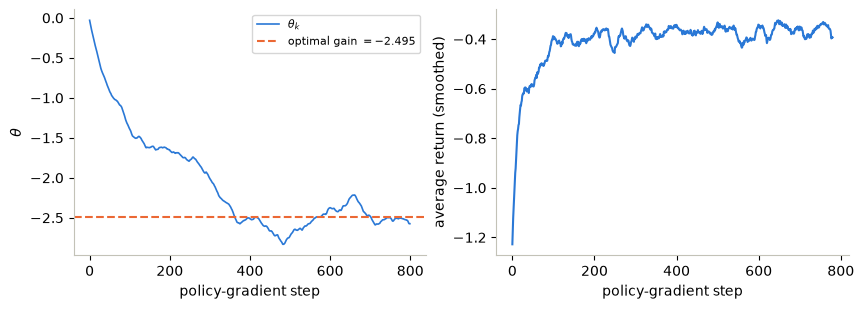

In [16]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.2))
a0.plot(theta_hist, color=BLUE, lw=1.2, label=r"$\theta_k$")
a0.axhline(theta_star, ls="--", color=ORANGE, label=rf"optimal gain $= {theta_star:.3f}$")
a0.set(xlabel="policy-gradient step", ylabel=r"$\theta$"); a0.legend(fontsize=8)
w = 20
a1.plot(np.convolve(ret_hist, np.ones(w) / w, "valid"), color=BLUE)
a1.set(xlabel="policy-gradient step", ylabel="average return (smoothed)")
plt.show()

The gain found from rollouts lands within a few per cent of the number the Bellman backup of §4 computes in
closed form, having seen neither the dynamics nor the cost. The remaining gap is not going to
close: the episodes are truncated at ten seconds, and stochastic gradient ascent on a noisy estimator does
not settle at a point, it wanders in a neighbourhood of one — which is exactly what the ragged $\theta_k$
trace shows. Reducing that variance is the whole of §10.

## 10. Proximal Policy Optimization

REINFORCE has two defects. Its gradient estimate is noisy, and each batch of data can be used for exactly
one step — after the update the data is off-policy and the estimator is no longer valid. PPO
([Schulman et al., 2017](https://arxiv.org/abs/1707.06347)) repairs both, and in doing so became the
default algorithm for continuous control and, later, for aligning language models.

**A critic, to reduce variance.** Train a value network $V_\phi$ alongside the policy. From the
temporal-difference residuals $\delta_t = r_{t+1} + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$, form the
*generalised advantage estimate*

$$A_t := \sum_{l\ge0}(\gamma\lambda)^l\,\delta_{t+l},$$

which interpolates between $\lambda = 0$ (one-step TD: low variance, biased by the critic's error) and
$\lambda = 1$ (the Monte-Carlo return minus a baseline: unbiased, high variance). It answers "how much
better was $a_t$ than what the critic expected of this state?". The critic is fitted to its own targets,
$L^{\text{VF}} = \mathbb{E}_t[(V_\phi(s_t) - R_t)^2]$ with $R_t = A_t + V_\phi(s_t)$.

**A clip, to reuse the batch.** Importance sampling lets a batch drawn under $\pi_{\theta_{\text{old}}}$
estimate the objective at a nearby $\theta$, through the ratio
$\varrho_t(\theta) = \pi_\theta(a_t\mid s_t)/\pi_{\theta_{\text{old}}}(a_t\mid s_t)$ — but only while the two
policies are close, since the variance of the estimate blows up with the ratio. PPO enforces closeness not
with a constraint but by flattening the objective outside a trust region:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\Big[\min\big(\varrho_t A_t,\;\mathrm{clip}(\varrho_t, 1-\epsilon, 1+\epsilon)A_t\big)\Big].$$

If $A_t > 0$ the objective stops rewarding increases in $\varrho_t$ beyond $1+\epsilon$; if $A_t<0$ it stops
rewarding decreases below $1-\epsilon$. Past the clip the gradient is zero, so there is no incentive to move
further, and the same batch can safely be reused for $K$ epochs. The $\min$ with the unclipped term keeps
the objective a lower bound, so a step that has already overshot is still pulled back.

**An entropy bonus, to keep exploring.** $\mathcal{H}[\pi_\theta] = -\mathbb{E}_{a\sim\pi_\theta}[\log \pi_\theta(a\mid s)]$
rewards keeping the action distribution broad. Unlike $\varepsilon$-greedy, it is part of the objective and
differentiable, so the policy decides for itself how much noise to keep. The full loss is

$$\mathcal{L} = -L^{\text{CLIP}} + c_1 L^{\text{VF}} - c_2\,\mathcal{H}[\pi_\theta].$$

### A pendulum that must swing itself up

The same test problem that notebook 05 gives to MPC, which solves it with full knowledge of the dynamics.
Here the agent gets $(\cos\theta,\sin\theta,\dot\theta/8)$, a torque bounded by $\lvert u \rvert \le 2$ — too weak to lift
the pendulum directly, so it must pump energy by rocking — and the reward

$$r = -\big(\bar\theta^2 + 0.1\,\dot\theta^2 + 0.001\,u^2\big), \qquad \bar\theta := \theta \bmod 2\pi \in [-\pi,\pi),$$

with $\theta = 0$ upright. It is told nothing else: not that $\theta$ is an angle, not that energy is
conserved, not that swinging is necessary.

In [17]:
G_ACC, L_ROD, M_ROD, DT_P, U_MAX = 9.81, 1.0, 1.0, 0.05, 2.0

def step(s, u):                                            # s = (theta, theta_dot), batched
    th, w = s[:, 0], s[:, 1]
    w = (w + DT_P * (1.5 * G_ACC / L_ROD * torch.sin(th)
                     + 3.0 * u.clamp(-U_MAX, U_MAX).squeeze(-1) / (M_ROD * L_ROD ** 2))).clamp(-8, 8)
    return torch.stack([th + DT_P * w, w], 1)

def obs(s):
    return torch.stack([torch.cos(s[:, 0]), torch.sin(s[:, 0]), s[:, 1] / 8], 1)

def reward(s, u):
    th = (s[:, 0] + np.pi) % (2 * np.pi) - np.pi           # 0 = upright
    return -(th ** 2 + 0.1 * s[:, 1] ** 2 + 0.001 * u.squeeze(-1) ** 2)

In [18]:
NENV, HOR, GAM, LAM, EPS_CLIP, K_EPOCH = 64, 200, 0.99, 0.95, 0.2, 10
mlp = lambda: nn.Sequential(nn.Linear(3, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
actor, critic, log_std = mlp(), mlp(), nn.Parameter(torch.zeros(1))
opt = torch.optim.Adam([*actor.parameters(), *critic.parameters(), log_std], lr=3e-3)

returns = []
for it in range(300):
    s = torch.stack([torch.rand(NENV) * 2 * np.pi - np.pi, torch.rand(NENV) * 2 - 1], 1)
    O, U, LP, R_, V_ = [], [], [], [], []
    with torch.no_grad():                                           # rollout under pi_old
        for t in range(HOR):
            o = obs(s); d = Normal(actor(o), log_std.exp()); u = d.sample()
            O.append(o); U.append(u); LP.append(d.log_prob(u).sum(-1)); V_.append(critic(o).squeeze(-1))
            R_.append(reward(s, u)); s = step(s, u)
        V_.append(critic(obs(s)).squeeze(-1))
    O, U, LP, R_, V_ = map(torch.stack, (O, U, LP, R_, V_))

    adv, g = torch.zeros(HOR, NENV), 0.0                            # generalised advantage estimate
    for t in reversed(range(HOR)):
        g = R_[t] + GAM * V_[t + 1] - V_[t] + GAM * LAM * g; adv[t] = g
    ret = adv + V_[:-1]
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    O, U = O.reshape(-1, 3), U.reshape(-1, 1)
    LP, adv, ret = LP.reshape(-1), adv.reshape(-1), ret.reshape(-1)

    for _ in range(K_EPOCH):                                        # reuse the batch K times
        d = Normal(actor(O), log_std.exp())
        rho = (d.log_prob(U).sum(-1) - LP).exp()
        clip = torch.min(rho * adv, rho.clamp(1 - EPS_CLIP, 1 + EPS_CLIP) * adv).mean()
        loss = -clip + 0.5 * ((critic(O).squeeze(-1) - ret) ** 2).mean() - 0.001 * d.entropy().sum(-1).mean()
        opt.zero_grad(); loss.backward(); opt.step()

    returns.append(R_.sum(0).mean().item())
    if it % 30 == 0:
        print(f"iteration {it:4d}:  average return = {returns[-1]:8.1f}")
print(f"final (mean of last 10): {np.mean(returns[-10:]):.1f}")

iteration    0:  average return =  -1253.6


iteration   30:  average return =   -845.9


iteration   60:  average return =   -216.3


iteration   90:  average return =   -178.7


iteration  120:  average return =   -185.6


...

iteration  180:  average return =   -150.8


iteration  210:  average return =   -163.4


iteration  240:  average return =   -149.7


iteration  270:  average return =   -146.9


final (mean of last 10): -153.3


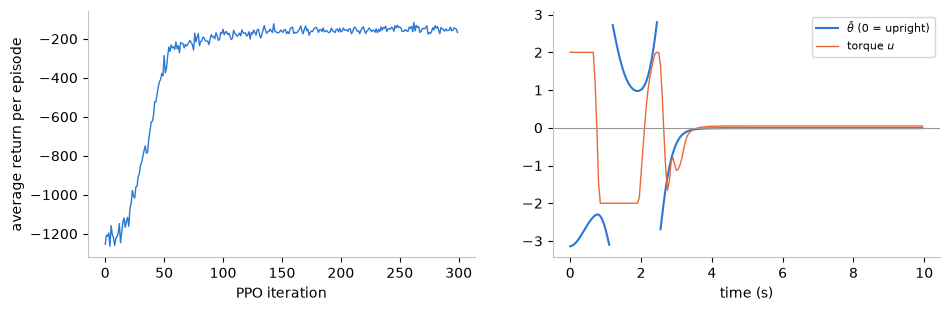

In [19]:
s, traj = torch.tensor([[np.pi, 0.0]]), []                 # hanging straight down, at rest
with torch.no_grad():
    for t in range(200):
        u = actor(obs(s))                                  # the mean action: no exploration noise
        traj.append([s[0, 0].item(), s[0, 1].item(), u.item()]); s = step(s, u)
traj = np.array(traj)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 3.2))
a0.plot(returns, color=BLUE, lw=1)
a0.set(xlabel="PPO iteration", ylabel="average return per episode")
tt = np.arange(200) * DT_P
th = (traj[:, 0] + np.pi) % (2 * np.pi) - np.pi
th[np.abs(np.diff(th, prepend=th[0])) > np.pi] = np.nan           # hide the jump at the wrap
a1.plot(tt, th, color=BLUE, label=r"$\bar\theta$ (0 = upright)")
a1.plot(tt, traj[:, 2].clip(-U_MAX, U_MAX), color=ORANGE, lw=1, label="torque $u$")
a1.axhline(0, color=GREY, lw=0.8); a1.set(xlabel="time (s)"); a1.legend(fontsize=8)
plt.show()

In [20]:
fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal", xticks=[], yticks=[])
ax.plot(0, 0, "o", ms=5, color=INK)
rod, = ax.plot([], [], lw=3, color=BLUE, solid_capstyle="round")
bob, = ax.plot([], [], "o", ms=10, color=ORANGE)

def draw(k):
    th = traj[2 * k, 0]
    x, y = np.sin(th), np.cos(th)                          # theta = 0 is straight up
    rod.set_data([0, x], [0, y]); bob.set_data([x], [y])
    ax.set_title(f"$t = {2 * k * DT_P:.1f}$ s")
anim = animation.FuncAnimation(fig, draw, frames=100, interval=60)
plt.close(fig)
HTML(anim.to_jshtml())

The agent rocks the pendulum back and forth, building amplitude until it has enough energy to carry past the
top, then catches it and holds it with small corrections. Nobody wrote an energy-pumping law. In notebook 05
the same manoeuvre falls out of repeatedly minimising a five-second prediction of a *known* nonlinear model;
here it falls out of a few million interactions with a model nobody has written down.

The honest comparison is in the cost. MPC needs $f$, and then solves the problem on the first attempt, from
any initial state, with a certificate attached. PPO needs no model, and spent roughly $4\times10^6$
environment steps — some two days of real pendulum time — to reach a policy that works well, carries no
guarantee, and would have to be retrained from scratch if the rod were shortened. That trade is the subject
of the last section.

## 11. What we left out

**Soft actor–critic and the entropy-regularised MDP.** PPO is on-policy and therefore wasteful. The
off-policy counterpart adds the entropy *into the objective itself*,
$V(s) = \mathbb{E}_{a\sim\pi}[Q(s,a) - \alpha\log\pi(a\mid s)]$, which turns the greedy step into a softmax
and yields [soft actor–critic](https://arxiv.org/abs/1801.01290). It is usually an order of magnitude more
sample-efficient than PPO on continuous control, at the price of the stability problems that come with
off-policy learning.

**Other things worth a notebook of their own.** *Model-based RL* learns $f$ and $r$ from data and then
plans against them — drop the neural ODE of notebook 02 into the place where MPC expects its model, and
that is the whole idea. *Inverse RL* infers $r$ from expert demonstrations; *imitation learning* skips $r$
and copies the expert directly. *Multi-agent* RL puts several learners in one environment, where the
stationarity the Markov property assumes is gone. *Meta-RL* learns across a family of environments.

**The difficulties, stated plainly.**

- *Exploration.* The $\varepsilon$-greedy rule of §6 is a placeholder. In a long-horizon task with a single
  reward at the end, random actions essentially never find it.
- *Credit assignment.* When the reward arrives a thousand steps after the decision that caused it, $\gamma^t$
  has already made the signal negligible.
- *Sample efficiency.* The pendulum above cost millions of steps for a problem a controls engineer solves
  with a pen. This is tolerable in a simulator and often prohibitive on hardware.
- *Reward design and reward hacking.* The agent optimises what you wrote, not what you meant. The
  $0.001\,u^2$ term in the pendulum reward is there to stop it chattering the torque; remove it and watch.
- *Instability.* Seeds, reward scaling and learning rates change results more than algorithmic choices do.
  Published comparisons are frequently within seed noise.

**MPC or RL?** It is not a competition so much as a question of where you want to spend. MPC needs a model
and online computation, and gives constraint satisfaction, stability certificates and immediate
adaptation to a new cost. RL needs data and offline computation, and gives a policy that is cheap to
evaluate and does not care how nasty the dynamics are. The interesting work is in between: *data-driven
MPC*, which learns the model and keeps the guarantees, and *model-based RL*, which plans against a learned
model. Yann LeCun's standing objection to pure RL — that it extracts too few bits per trial to ever be the
main ingredient of intelligence — is a statement about exactly this axis.

**And the mathematics we only touched.** Viscosity solutions of the HJB equation; convergence rates of
stochastic approximation; the geometry behind the trust region in PPO (natural gradients and TRPO);
continuous-time RL, where the Bellman backup becomes an SDE problem and recent work is actively reopening
the question; and the fact that score-based diffusion sampling is itself a stochastic optimal control
problem, whose optimal control turns out to be the score — which is where notebook 06 begins.

## References

**Origins**

1. E. L. Thorndike, *Animal Intelligence: An Experimental Study of the Associative Processes in Animals*,
   Psychological Review Monograph Supplement **2** (1898).
2. B. F. Skinner, *The Behavior of Organisms: An Experimental Analysis*, Appleton-Century, 1938.
3. H. Robbins, *Some aspects of the sequential design of experiments*, Bulletin of the AMS **58** (1952),
   527–535.
4. R. Bellman, *On the theory of dynamic programming*, PNAS **38** (1952), 716–719.
5. R. Bellman, *Dynamic Programming*, Princeton University Press, 1957.
6. R. A. Howard, *Dynamic Programming and Markov Processes*, MIT Press, 1960.
7. L. S. Pontryagin, V. G. Boltyanskii, R. V. Gamkrelidze, E. F. Mishchenko, *The Mathematical Theory of
   Optimal Processes*, Interscience, 1962.
8. M. G. Crandall, P.-L. Lions, *Viscosity solutions of Hamilton–Jacobi equations*, Transactions of the AMS
   **277** (1983), 1–42.

**Reinforcement learning**

9. R. S. Sutton, *Learning to predict by the methods of temporal differences*, Machine Learning **3**
   (1988), 9–44.
10. C. J. C. H. Watkins, *Learning from Delayed Rewards*, PhD thesis, University of Cambridge, 1989.
11. C. J. C. H. Watkins, P. Dayan, *Q-learning*, Machine Learning **8** (1992), 279–292.
12. R. J. Williams, *Simple statistical gradient-following algorithms for connectionist reinforcement
    learning*, Machine Learning **8** (1992), 229–256.
13. W. Schultz, P. Dayan, P. R. Montague, *A neural substrate of prediction and reward*, Science **275**
    (1997), 1593–1599.
14. R. S. Sutton, D. McAllester, S. Singh, Y. Mansour, *Policy gradient methods for reinforcement learning
    with function approximation*, NeurIPS, 2000.
15. R. S. Sutton, A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd ed., MIT Press, 2018.

**Deep reinforcement learning**

16. V. Mnih et al., *Human-level control through deep reinforcement learning*, Nature **518** (2015),
    529–533.
17. D. Silver et al., *Mastering the game of Go with deep neural networks and tree search*, Nature **529**
    (2016), 484–489.
18. J. Schulman, P. Moritz, S. Levine, M. Jordan, P. Abbeel, *High-dimensional continuous control using
    generalized advantage estimation*, ICLR, 2016.
19. J. Schulman, F. Wolski, P. Dhariwal, A. Radford, O. Klimov, *Proximal policy optimization algorithms*,
    arXiv:1707.06347, 2017.
20. T. Haarnoja, A. Zhou, P. Abbeel, S. Levine, *Soft actor-critic: off-policy maximum entropy deep
    reinforcement learning with a stochastic actor*, ICML, 2018.

**Control, and the bridge back**

21. D. P. Bertsekas, *Reinforcement Learning and Optimal Control*, Athena Scientific, 2019.
22. D. Q. Mayne, J. B. Rawlings, C. V. Rao, P. O. M. Scokaert, *Constrained model predictive control:
    stability and optimality*, Automatica **36** (2000), 789–814.
23. G. Fabbri, F. Gozzi, A. Święch, *Stochastic Optimal Control in Infinite Dimension*, Springer, 2017.
24. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, *Neural ordinary differential equations*,
    NeurIPS, 2018.